<a href="https://colab.research.google.com/github/aniketbhaumik/GA_WarmStart/blob/main/GA_MCS_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, random_split
import os
from math import floor

In [ ]:
# Constants
POPULATION_SIZE = 50
CHROMOSOME_LENGTH = 10  # Supports x from [0, 1024]
GENERATION_LIMIT = 20
RUNS = 15000

In [ ]:
def fitness_function(x):
    return x ** 2

In [ ]:
class Individual:
    def __init__(self, chromosome=None, origin="random"):
        self.chromosome = chromosome or [random.randint(0, 1) for _ in range(CHROMOSOME_LENGTH)]
        self.origin = origin,
        self.decimal = self.decode()
        self.fitness = fitness_function(self.decimal)
        self.update()

    def decode(self):
        return int("".join(map(str, self.chromosome)), 2)

    def mutate(self, mutation_rate=0.15):
        for i in range(len(self.chromosome)):
            if random.random() < mutation_rate:
                self.chromosome[i] = 1 - self.chromosome[i]
        self.update()

    def crossover(self, other):
        child_chromosome = []
        for i in range(CHROMOSOME_LENGTH):
            r = random.random()
            if r < 0.45:
                child_chromosome.append(self.chromosome[i])
            elif r < 0.90:
                child_chromosome.append(other.chromosome[i])
            else:
                child_chromosome.append(random.randint(0, 1))
        return Individual(child_chromosome)

    def update(self):
        self.decimal = self.decode()
        self.fitness = fitness_function(self.decimal)



In [ ]:
def create_population():
    return [Individual() for _ in range(POPULATION_SIZE)]

In [ ]:
def run_ga_tracking():

    """
      Run the standard Genetic Algorithm (GA) for a number of generations
      This function evolves a population of candidate solutions and
      tracks the best fitness value over time
    """
    tracking_data = {}

    for _ in tqdm(range(RUNS)):
        individual_tracking = {}
        population = create_population()

        best_fitness = -float("inf")
        consecutive_stagnation = 0
        stagnation_limit = 3
        last_executing_generation = 0

        for generation in range(GENERATION_LIMIT):
            population.sort(key=lambda ind: ind.fitness, reverse=True)
            last_executing_generation = generation

            for ind in population:
                key = tuple(ind.chromosome)
                if key not in individual_tracking:
                    individual_tracking[key] = {'count': 1, 'first': generation, 'last': generation}
                else:
                    individual_tracking[key]['count'] += 1
                    individual_tracking[key]['last'] = generation

            current_best_fitness = population[0].fitness
            if current_best_fitness == best_fitness:
                consecutive_stagnation += 1
            else:
                best_fitness = current_best_fitness
                consecutive_stagnation = 0

            if consecutive_stagnation >= stagnation_limit:
                break

            # Elitism: top 10% carry over
            top_n = max(1, POPULATION_SIZE // 10)
            new_population = population[:top_n]

            while len(new_population) < POPULATION_SIZE:
                # parent1, parent2 = random.sample(population[:POPULATION_SIZE // 2], 2)
                parent1, parent2 = random.sample(population[top_n : POPULATION_SIZE // 2], 2)
                child = parent1.crossover(parent2)
                child.mutate()
                new_population.append(child)

            population = new_population

        # Aggregate per run
        for key, v in individual_tracking.items():
            dec_val = int("".join(map(str, key)), 2)
            first, last = v['first'], v['last']
            survival = last - first + 1
            last_diff = last_executing_generation - last

            if key not in tracking_data:
                tracking_data[key] = {
                    'Decimal Value': dec_val,
                    'Total Appearances': v['count'],
                    'First_Appearance_Sum': first,
                    'Last_Appearance_Sum': last,
                    'Survival_Gen_Sum': survival,
                    'LastGen_Diff_Total': last_diff,
                    'Runs_Appeared': 1
                }
            else:
                td = tracking_data[key]
                td['Total Appearances'] += v['count']
                td['First_Appearance_Sum'] += first
                td['Last_Appearance_Sum'] += last
                td['Survival_Gen_Sum'] += survival
                td['LastGen_Diff_Total'] += last_diff
                td['Runs_Appeared'] += 1

    # Final DataFrame with means
    tracking_df = pd.DataFrame([
        {
            'Individual': key,
            'Decimal Value': v['Decimal Value'],
            'Total Appearances': v['Total Appearances'],
            'First_Appearance': v['First_Appearance_Sum'] / v['Runs_Appeared'],
            'Last_Appearance': v['Last_Appearance_Sum'] / v['Runs_Appeared'],
            'Survival_Generations': v['Survival_Gen_Sum'] / v['Runs_Appeared'],
            'LastGen_Diff': v['LastGen_Diff_Total'] / v['Runs_Appeared'],
            'Mean Total Appearances': v['Total Appearances'] / RUNS
        }
        for key, v in tracking_data.items()
    ])

    return tracking_df


In [ ]:
tracking_df = run_ga_tracking()
tracking_df.head()

100%|██████████| 15000/15000 [01:14<00:00, 200.12it/s]


,Individual,Decimal Value,Total Appearances,First_Appearance,Last_Appearance,Survival_Generations,LastGen_Diff,Mean Total Appearances
0,"(1, 1, 1, 1, 0, 1, 1, 0, 0, 1)",985,16172,3.604485,5.101055,2.496570,1.594855,1.078133
1,"(1, 1, 1, 1, 0, 1, 1, 0, 0, 0)",984,15932,3.634111,5.113879,2.479768,1.602478,1.062133
2,"(1, 1, 1, 1, 0, 1, 0, 0, 1, 1)",979,16212,3.598046,5.066349,2.468304,1.614890,1.080800
3,"(1, 1, 1, 0, 1, 1, 0, 0, 1, 0)",946,12623,3.467353,4.658082,2.190728,1.993735,0.841533
4,"(1, 1, 1, 0, 1, 1, 0, 0, 0, 1)",945,12267,3.469192,4.620407,2.151215,1.999011,0.817800


In [ ]:
tracking_df.shape

(1024, 8)

In [ ]:
# labels for predicting till how many generations will an individual last
targets  = tracking_df['Last_Appearance']

In [ ]:
tracking_df['Appearances_per_Gen'] = tracking_df['Total Appearances'] / tracking_df['Survival_Generations'].replace(0, 1)

In [ ]:
# input features for neural network
features = [
    'Decimal Value',
    'Total Appearances',
    'First_Appearance',
    'Survival_Generations',
    'LastGen_Diff',
    'Mean Total Appearances',
    'Appearances_per_Gen'
]

In [ ]:
X = tracking_df[features].values
# y = tracking_df['Survived_Till_Last'].values
y = targets.values

In [ ]:
X.shape, y.shape

((1024, 7), (1024,))

In [ ]:
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).squeeze()


In [ ]:
indices = tracking_df.index.to_numpy()

# train-test split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_scaled, y_scaled, indices, test_size=0.2, random_state=42
)

In [ ]:
class GADataset(Dataset):
    """Custom dataset for GA data."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        # self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)


    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
full_train_dataset = GADataset(X_train, y_train)
# Split train into train and val (85% train, 15% val)
len_ = len(full_train_dataset)
train_size = int(0.85 * len_)
val_size = len_ - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Create test dataset
test_dataset = GADataset(X_test, y_test)

# create dataloader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# neural network class
class SurvivalPredictor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer): # device='cpu'
  """
  Train the model for one epoch.
  """

  model.train()
  epoch_loss = []

  # Wrap train_loader with tqdm for progress bar
  pbar = tqdm(train_loader, desc="Training", leave=False)
  for X_batch, y_batch in pbar:
    X_batch, y_batch = X_batch, y_batch
    # print(f"X:{X_batch.shape}, Y:{y_batch.shape}")
    optimizer.zero_grad()
    outputs = model(X_batch)
    if y_batch.dim() == 1:
      y_batch = y_batch.unsqueeze(1)
    loss = criterion(outputs, y_batch)

    loss.backward()
    optimizer.step()

    epoch_loss.append(loss.item())

  return np.mean(epoch_loss)

def validate_one_epoch(model, val_loader, criterion):

  """
  Validate the model for one epoch.
  """
  model.eval()
  val_loss = 0.0
  with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Validating", leave=False):
      inputs, labels = inputs, labels
      outputs = model(inputs)
      if labels.dim() == 1:
        labels = labels.unsqueeze(1)
      loss = criterion(outputs, labels)
      val_loss += loss.item()

  avg_val_loss = val_loss / len(val_loader)
  return avg_val_loss

In [ ]:
"""
Defining the training script
"""
# Define save directory and create it if it doesn't exist
save_dir = "models"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "best_model.pth")

train_losses = []
val_losses = []
best_val_loss = float('inf')

# initialise model
model = SurvivalPredictor(input_dim=X.shape[1])

# Training loop
num_epochs = 30


optimizer = optim.Adam(model.parameters(), lr=0.0001) # , weight_decay=1e-5

# loss
criterion = nn.MSELoss()



for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate_one_epoch(model, val_loader, criterion)

    # train_loss = train_one_epoch(model, train_loader, directional_loss, optimizer, device)
    # val_loss = validate_one_epoch(model, val_loader, directional_loss, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print(f"Saved new best model with val loss {best_val_loss:.6f}")

print(f"Final best model saved to {save_path}")



Epoch 1/30


Train Loss: 0.828482 | Val Loss: 0.863134
Saved new best model with val loss 0.863134

Epoch 2/30


Train Loss: 0.601908 | Val Loss: 0.577992
Saved new best model with val loss 0.577992

Epoch 3/30


Train Loss: 0.414260 | Val Loss: 0.362869
Saved new best model with val loss 0.362869

Epoch 4/30


Train Loss: 0.267927 | Val Loss: 0.199410
Saved new best model with val loss 0.199410

Epoch 5/30


...

Train Loss: 0.014494 | Val Loss: 0.001792
Saved new best model with val loss 0.001792

Epoch 27/30


Train Loss: 0.017097 | Val Loss: 0.001648
Saved new best model with val loss 0.001648

Epoch 28/30


Train Loss: 0.015595 | Val Loss: 0.001609
Saved new best model with val loss 0.001609

Epoch 29/30


Train Loss: 0.017704 | Val Loss: 0.001809

Epoch 30/30


Train Loss: 0.015815 | Val Loss: 0.001429
Saved new best model with val loss 0.001429
Final best model saved to models/best_model.pth


In [ ]:
training_loss = np.array(train_losses).mean()
validation_loss = np.array(val_losses).mean()
print(f"Training Loss: {training_loss:.6f} | Validation Loss: {validation_loss:.6f}")

Training Loss: 0.126824 | Validation Loss: 0.042013


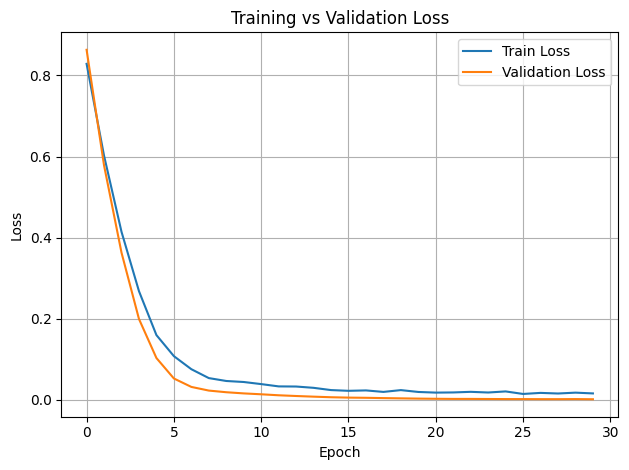

In [ ]:
# loss curve
# plt.figure(figsize=(8, 5))
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_model(model, test_loader, tracking_df, idx_test):
    model.eval()
    y_true_scaled = []
    y_pred_scaled = []

    with torch.no_grad():
      for inputs, targets in test_loader:
        outputs = model(inputs)
        y_true_scaled.extend(targets.squeeze().tolist())
        y_pred_scaled.extend(outputs.squeeze().tolist())

    y_true_scaled = np.array(y_true_scaled).reshape(-1, 1)
    y_pred_scaled = np.array(y_pred_scaled).reshape(-1, 1)

    # Inverse scale
    y_true = scaler_y.inverse_transform(y_true_scaled).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
    # y_pred = np.floor(y_pred)

    # map predictions to orginal data
    pred_df = tracking_df.loc[idx_test].copy()
    pred_df['Actual_Last_Appearance'] = y_true
    pred_df['Predicted_Last_Appearance'] = y_pred

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\nTest Performance:")
    print(f"  MSE  : {mse:.6f}")
    print(f"  MAE  : {mae:.6f}")
    print(f"  R^2  : {r2:.6f}")

    # Scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.xlabel("Actual Last Generation")
    plt.ylabel("Predicted Last Generation")
    plt.title("Actual vs Predicted Survival Generation")
    # plt.legend()
    plt.grid(True)
    plt.show()

    return pred_df



Test Performance:
  MSE  : 0.003044
  MAE  : 0.043848
  R^2  : 0.997722


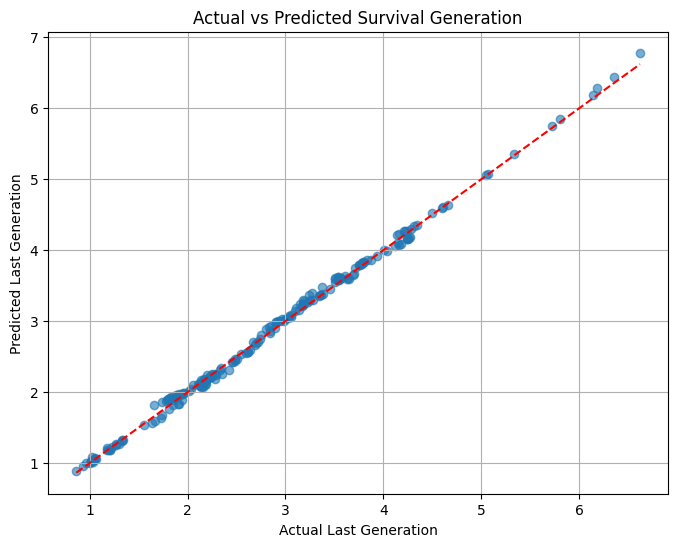

In [ ]:
model.load_state_dict(torch.load(save_path))
pred_df  = evaluate_model(model, test_loader, tracking_df, idx_test)

In [ ]:
def initialize_population_warmstart(model, tracking_df, scaler_X, scaler_y, top_k=5, mid_k=5):
    """
    initialise the population with top-k and mid-level individuals
    for warm start GA

    """
    # Preprocess features
    X_features = tracking_df[features].values
    X_scaled = scaler_X.transform(X_features)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    # Predict survival generations
    model.eval()
    with torch.no_grad():
        predictions_scaled = model(X_tensor).numpy()
    predictions = scaler_y.inverse_transform(predictions_scaled)

    # Attach predictions to dataframe
    temp_df = tracking_df.copy()
    temp_df['Predicted_LastGen'] = predictions

    # Get top-k predicted individuals
    top_individuals = temp_df.sort_values(by='Predicted_LastGen', ascending=False).head(top_k)

    # Get mid-level individuals (middle 50%)
    middle_range_df = temp_df.sort_values(by='Predicted_LastGen').iloc[len(temp_df)//4 : -len(temp_df)//4]
    mid_individuals = middle_range_df.sample(n=mid_k, random_state=42)  # Reproducible

    # Extract chromosomes
    top_chromosomes = [list(x) for x in top_individuals['Individual'].values]
    mid_chromosomes = [list(x) for x in mid_individuals['Individual'].values]

    # Initialize population
    # population = [Individual(chromosome=chrom) for chrom in top_chromosomes + mid_chromosomes]
    population = [Individual(chromosome=chrom, origin='top') for chrom in top_chromosomes]
    population += [Individual(chromosome=chrom, origin='mid') for chrom in mid_chromosomes]

    # Fill the rest with random individuals
    while len(population) < POPULATION_SIZE:
        population.append(Individual())

    return population


def run_ga_with_warmstart(model, tracking_df, scaler_X, scaler_y, top_k=5, mid_k=5):

    """
      Run the Genetic Algorithm (GA) with smart initialisation based on the predictions of neural network
      Uses a adaptive mutation strategy for top_k and mid_k candidate solutions and
      tracks the best fitness value over time
    """
    population = initialize_population_warmstart(model, tracking_df, scaler_X, scaler_y, top_k, mid_k)
    best_fitness_progress = []

    for gen in range(GENERATION_LIMIT):
        population = sorted(population, key=lambda ind: ind.fitness, reverse=True)
        best_fitness_progress.append(population[0].fitness)

        next_generation = population[:5]  # Elitism

        while len(next_generation) < POPULATION_SIZE:
            parent1, parent2 = random.sample(population[:25], 2)
            child = parent1.crossover(parent2)

            # Adaptive mutation: higher in early gens
            # mutation_rate = 0.3 if gen < 5 else 0.1
            if parent1.origin == 'mid' or parent2.origin == 'mid':
              mutation_rate = 0.4
            else:
              mutation_rate = 0.1

            child.mutate(mutation_rate=mutation_rate)


            next_generation.append(child)

        population = next_generation
    return best_fitness_progress


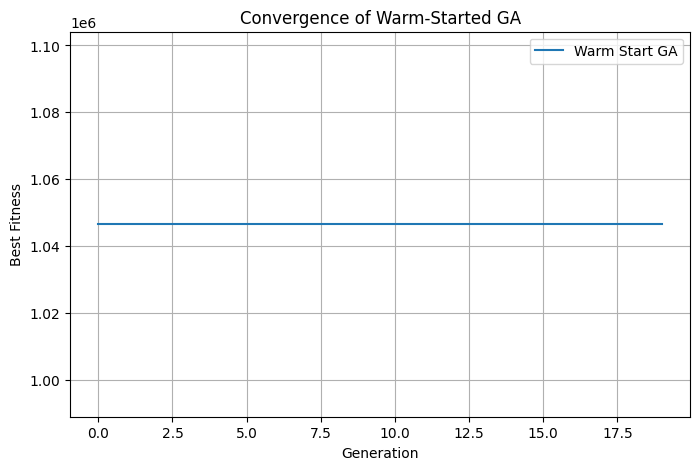

In [ ]:
# Run the warm-started GA
warmstart_fitness = run_ga_with_warmstart(model, tracking_df, scaler_X, scaler_y, top_k=3, mid_k=7)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(warmstart_fitness, label="Warm Start GA")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Convergence of Warm-Started GA")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Compare Warm-Start vs Baseline GA

def run_baseline_ga():
    population = [Individual() for _ in range(POPULATION_SIZE)]
    best_fitness_progress = []

    for gen in range(GENERATION_LIMIT):
        population = sorted(population, key=lambda ind: ind.fitness, reverse=True)
        best_fitness_progress.append(population[0].fitness)

        next_generation = population[:5]  # Elitism

        while len(next_generation) < POPULATION_SIZE:
            parent1, parent2 = random.sample(population[:25], 2)
            child = parent1.crossover(parent2)
            child.mutate(mutation_rate=0.1)
            next_generation.append(child)

        population = next_generation
    return best_fitness_progress

# Run multiple trials for more robust comparison
def compare_ga_runs(model, tracking_df, scaler_X, scaler_y, top_k=5, mid_k=5, trials=10):
    warm_runs = []
    base_runs = []

    for _ in range(trials):
        warm = run_ga_with_warmstart(model, tracking_df, scaler_X, scaler_y, top_k, mid_k)
        base = run_baseline_ga()
        warm_runs.append(warm)
        base_runs.append(base)

    warm_avg = np.mean(warm_runs, axis=0)
    base_avg = np.mean(base_runs, axis=0)

    # Plot comparison
    plt.figure() # figsize=(10, 6)
    plt.plot(base_avg, label="Baseline GA", linestyle='--')
    plt.plot(warm_avg, label="Warm Start GA", linestyle='-')
    plt.xlabel("Generation")
    plt.ylabel("Average Best Fitness")
    plt.title(f"GA Convergence Comparison (Over {trials} Trials)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # Optional: report convergence generation (when 95% of max is reached)
    def time_to_converge(fitness_progress):
        max_fit = max(fitness_progress)
        threshold = 0.95 * max_fit
        for i, val in enumerate(fitness_progress):
            if val >= threshold:
                return i
        return GENERATION_LIMIT

    warm_times = [time_to_converge(run) for run in warm_runs]
    base_times = [time_to_converge(run) for run in base_runs]

    print(f"Average convergence generation (95% max fitness):")
    print(f"  Baseline GA: {np.mean(base_times):.2f} ± {np.std(base_times):.2f}")
    print(f"  Warm Start GA: {np.mean(warm_times):.2f} ± {np.std(warm_times):.2f}")




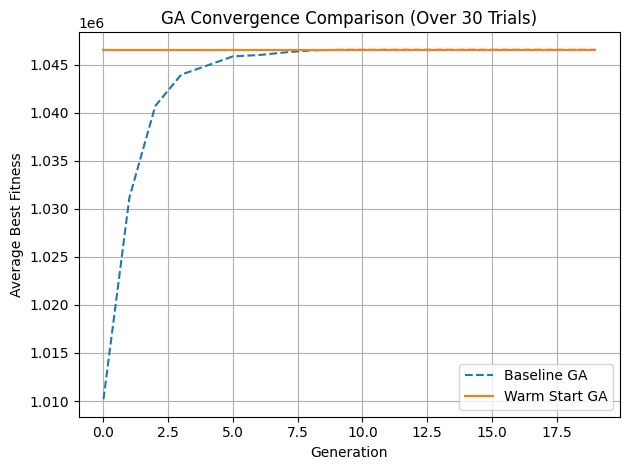

Average convergence generation (95% max fitness):
  Baseline GA: 0.27 ± 0.44
  Warm Start GA: 0.00 ± 0.00


In [ ]:
compare_ga_runs(model, tracking_df, scaler_X, scaler_y, top_k=5, mid_k=5, trials=30)


In [ ]:
def plot_multiple_convergence_configs(model, tracking_df, scaler_X, scaler_y, configs, trials=30):
    plt.figure(figsize=(10, 6))

    for config in configs:
        top_k, mid_k = config["top_k"], config["mid_k"]
        label = f"Warm Start GA (top={top_k}, mid={mid_k})"
        warm_runs = []

        for _ in range(trials):
            warm = run_ga_with_warmstart(model, tracking_df, scaler_X, scaler_y, top_k=top_k, mid_k=mid_k)
            warm_runs.append(warm)

        avg_curve = np.mean(warm_runs, axis=0)
        plt.plot(avg_curve, label=label)

    # Add baseline for reference
    base_runs = [run_baseline_ga() for _ in range(trials)]
    base_avg = np.mean(base_runs, axis=0)
    plt.plot(base_avg, '--', label="Baseline GA", color='black')

    plt.xlabel("Generation")
    plt.ylabel("Average Best Fitness")
    plt.title(f"Warm Start Configurations vs Baseline (Over {trials} Trials)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


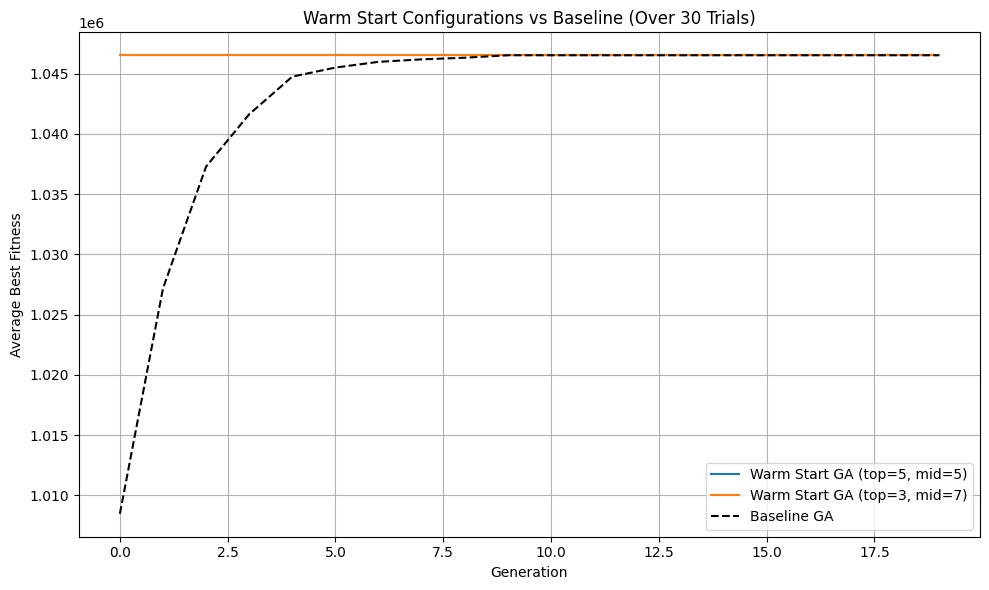

In [ ]:
"""
  setting the number of top_k and mid_k individuals to test
"""

configs = [
    {"top_k": 5, "mid_k": 5},
    {"top_k": 3, "mid_k": 7}
]

plot_multiple_convergence_configs(model, tracking_df, scaler_X, scaler_y, configs, trials=30)
